# 🤟 LSTM Hand Sign Language Model Training

**Train and deploy a deep learning model for hand gesture recognition using LSTM networks.**

This notebook guides you through training on Google Colab. Perfect for beginners—just follow the green-highlighted execution paths below.

## 📋 Table of Contents

| Section | Time | For Whom |
|---------|------|----------|
| **[Setup](#setup)** | 2 min | Everyone |
| **[Data Loading](#data-loading)** | 3 min | Everyone |
| **[Model Training](#training)** | 15-30 min | Everyone |
| **[Evaluation](#evaluation)** | 5 min | Everyone |
| **[Save & Export](#save)** | 2 min | Everyone |
| **[Inference (Optional)](#inference)** | 5 min | Everyone |

---

## ⚡ Quick Start: Two Execution Paths

### 🟢 PATH A: Quick Start (Already have preprocessed data)
**Time: ~20 minutes | Best for: Testing, quick iteration**

```
1. RUN: Cell "Imports & Dependencies"
2. RUN: Cell "Environment Setup"
3. RUN: Cell "Load Preprocessed Data"
4. RUN: Cell "Validate Dataset"
5. RUN: Cell "Prepare Train/Validation Split"
6. RUN: Cell "Define LSTM Model"
7. RUN: Cell "Train Model (Quick)"
8. RUN: Cell "Evaluate Model"
9. RUN: Cell "Save Model & Artifacts"
→ DONE! Your model is saved to models/gesture_model.h5
```

### 🔵 PATH B: Full Pipeline (Start from raw videos)
**Time: ~45 minutes | Best for: Complete workflow with preprocessing**

```
1. RUN: Cell "Imports & Dependencies"
2. RUN: Cell "Environment Setup"
3. RUN: Cell "Mount Google Drive" (Colab only)
4. RUN: Cell "Preprocess Video Data"
5. (Then continue with steps 4-9 from PATH A)
```

---

## 📚 Prerequisites

**Required files** (you must have these before starting):
- `data/X_data.npy` — Preprocessed sequences of hand landmarks (shape: samples × sequence_length × features)
- `data/y_data.npy` — Corresponding class labels (shape: samples,)
- `models/wlasl_labels.npy` (optional) — Human-readable class names

**No data yet?** Use PATH B above to preprocess from raw videos, or upload/mount your data via Google Drive.

---

## 🎯 Learning Outcomes

After running this notebook, you will:
- ✅ Understand how LSTM networks process sequential hand movement data
- ✅ Train a model from scratch on your data
- ✅ Evaluate model performance with confusion matrices
- ✅ Save trained artifacts (weights, labels, metadata) for deployment
- ✅ Make predictions on new hand sequences

---

# 🔧 PHASE 1: Setup & Imports

**What happens here:** Install dependencies, import libraries, detect if running in Colab or local environment.

**Expected time:** 2 minutes
**Status:** ⏳ Start here (run next cell)

## ℹ️ Helpful Tips

### If you're new to notebooks:
- **Run cells in order** (use ▶️ button or press Shift+Enter)
- **Turn on line numbers** to match this guide (View → Line Numbers)
- **If something breaks**, scroll back and re-run from a previous cell

### Choosing your path:
- **Already have `X_data.npy` and `y_data.npy`?** Jump to "Load Preprocessed Data" (PATH A)
- **Starting from raw videos?** Start from "Mount Google Drive" (PATH B)

### Need help?
- 🔴 **Error in a cell?** → Read the error message, scroll up to check if a required cell was skipped
- ❓ **Don't understand something?** → Check the markdown cell above the code for explanation
- ⏸️ **Cell taking too long?** → Click the ⏹ button to stop it

In [60]:
# ✅ IMPORTS & DEPENDENCIES
# Uncomment the line below if running on Google Colab for the first time:
# %pip install -q tensorflow numpy scikit-learn matplotlib seaborn

import json
import sys
from datetime import datetime
from pathlib import Path

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Deep learning
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

# Print environment info
print("=" * 60)
print("✅ ALL IMPORTS SUCCESSFUL")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Python version: {sys.version.split()[0]}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

✅ ALL IMPORTS SUCCESSFUL
TensorFlow version: 2.19.0
Python version: 3.12.13
Timestamp: 2026-03-28 23:50:35


In [61]:
# [OPTIONAL] Preprocessing Setup - Only run if you have raw videos
# This loads the video preprocessing pipeline. If you already have X_data.npy and y_data.npy, skip this.

import importlib
import os

# Load the preprocessing pipeline
src_path = Path('src').resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

try:
    import video_preprocessing_pipeline
    importlib.reload(video_preprocessing_pipeline)
    from video_preprocessing_pipeline import VideoPreprocessingPipeline
    HAS_PIPELINE = True
    print("✅ Video preprocessing pipeline loaded successfully")
except ImportError as e:
    print(f"⚠️  Video preprocessing pipeline not available: {e}")
    print("   → You can still proceed if you have X_data.npy and y_data.npy")
    HAS_PIPELINE = False

# Try to load widgets for interactive dashboard (optional)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("Note: ipywidgets not available, will use text output instead")

✅ Video preprocessing pipeline loaded successfully


In [62]:
# 🎬 PREPROCESS VIDEO DATA
# Converts raw videos → preprocessed sequences (X_data.npy, y_data.npy)
# ⏱️  This cell may take 20-30 minutes depending on video count

if not HAS_PIPELINE:
    print("❌ Pipeline not loaded. Run the 'Preprocessing Setup' cell first.")
else:
    pipeline = VideoPreprocessingPipeline(video_dir='data/videos', output_dir='data')
    
    print("=" * 60)
    print("🔄 STARTING VIDEO PREPROCESSING")
    print("=" * 60)
    print(f"Input videos: {pipeline.video_dir}")
    print(f"Output location: {pipeline.output_dir}")
    print(f"Expected output files:")
    print(f"  - data/X_data.npy (sequences)")
    print(f"  - data/y_data.npy (labels)")
    print()
    
    try:
        X_data, y_data, metadata = pipeline.process_videos()
        pipeline.save_data(X_data, y_data, metadata)
        
        print("=" * 60)
        print("✅ PREPROCESSING COMPLETE")
        print("=" * 60)
        print(f"X_data shape: {X_data.shape}")
        print(f"y_data shape: {y_data.shape}")
        print(f"✅ Ready for training! Run 'Load Preprocessed Data' next.")
    except Exception as e:
        print(f"❌ Error during preprocessing: {e}")
        print("   Try checking your video folder and permissions")

🔄 STARTING VIDEO PREPROCESSING
Input videos: data/videos
Output location: data
Expected output files:
  - data/X_data.npy (sequences)
  - data/y_data.npy (labels)

✅ PREPROCESSING COMPLETE
X_data shape: (1, 30, 8)
y_data shape: (1,)
✅ Ready for training! Run 'Load Preprocessed Data' next.


---

# 📦 PHASE 2: Data Loading & Validation

Choose **ONE** of the paths below based on where your data is located.

## PATH A: Load Preprocessed Data (Quick)
**Use this if:** You already have `X_data.npy` and `y_data.npy` files

→ Run the **"Load Preprocessed Data"** cell below

## PATH B: Preprocess from Raw Videos (Full)
**Use this if:** You have raw video files in Google Drive

→ Run these cells in order:
1. Mount Google Drive
2. Preprocess Video Data
3. Then continue with PATH A validation

**Expected time:** 3-5 minutes for loading, 20-30 minutes for preprocessing
**Status:** Choose your path above ⬇️

In [63]:
# 🔗 MOUNT GOOGLE DRIVE
# This connects your Google Drive to Colab. 
# You'll see an auth link—click it, select your account, copy the code, paste it here.

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")
except ImportError:
    print("⚠️  Not running on Google Colab (drive mount not available)")
    print("   If running locally, make sure data files are in ./data/")

# --------
# 📍 WHERE TO FIND YOUR DATA
# --------
# Update the path below to match your Google Drive folder structure
# Example: /content/drive/MyDrive/YourProjectFolder/data/videos

from pathlib import Path

drive_video_path = Path('/content/drive/MyDrive/handsign_detection_dynamic/data/videos')
local_video_path = Path('data/videos')

print(f"\nLooking for videos at: {drive_video_path}")

if drive_video_path.exists():
    # Create symlink
    if local_video_path.exists() and not local_video_path.is_symlink():
        import shutil
        shutil.rmtree(local_video_path)
    
    if not local_video_path.exists():
        import os
        os.symlink(drive_video_path, local_video_path)
        print(f"✅ Linked {drive_video_path} → {local_video_path}")
    
    # Count files
    video_extensions = {'.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv'}
    video_files = [f for f in local_video_path.rglob('*') 
                   if f.is_file() and f.suffix.lower() in video_extensions]
    print(f"✅ Found {len(video_files)} video files ready for preprocessing")
else:
    print(f"❌ Could not find {drive_video_path}")
    print("   → Check the folder name in your Google Drive and update the path above")
    print("   → Or upload files to ./data/videos/ manually")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!

Looking for videos at: /content/drive/MyDrive/handsign_detection_dynamic/data/videos
✅ Found 11978 video files ready for preprocessing


In [64]:
# ℹ️ INFO: How to Save Model Weights & Artifacts
# 
# ⚠️  SKIP THIS FOR NOW - Model saving happens automatically LATER
# See the "Save Model & Artifacts" cell in PHASE 5 for the complete saving process
#
# ========================================
# REFERENCE CODE (for your knowledge):
# ========================================
#
# After training completes, you can save the model like this:
#
# Option 1: Save full model (RECOMMENDED)
# ────────────────────────────────────────
#   import os
#   from pathlib import Path
#   
#   models_dir = Path('models')
#   models_dir.mkdir(parents=True, exist_ok=True)
#   
#   model.save('models/gesture_model.h5')
#   print('✅ Full model saved (weights + architecture)')
#
# Option 2: Save only weights
# ────────────────────────────────────────
#   weights_path = models_dir / 'gesture_weights.weights.h5'
#   model.save_weights(weights_path)
#   print('✅ Weights-only file saved')
#
# ⏭️  NEXT STEP: Scroll down to "PHASE 3: Model Training" to proceed
# 
print("=" * 60)
print("ℹ️  This is a REFERENCE cell - don't modify it!")
print("=" * 60)
print("\n✅ Your notebook is correctly organized.")
print("   The actual model saving happens AFTER training.")
print("\n→ Next: Scroll down to 'PHASE 3: Model Training'")
print("=" * 60)

ℹ️  This is a REFERENCE cell - don't modify it!

✅ Your notebook is correctly organized.
   The actual model saving happens AFTER training.

→ Next: Scroll down to 'PHASE 3: Model Training'


In [65]:
import numpy as np

print(f'Structure of y_data:')
print(f' - Type: {type(y_data)}')
print(f' - Shape: {y_data.shape} (Number of samples,)')
print(f' - Data Type: {y_data.dtype}')
print(f' - Unique Class IDs: {np.unique(y_data)}')

# Show first few elements if not empty
if len(y_data) > 0:
    print(f' - First 5 labels: {y_data[:5]}')

print('\nExplanation:')
print('Each integer in y_data acts as an index for the class names.')
print('Before training, these are typically converted to "One-Hot" encoding (y_cat),')
print('turning a single integer into a vector of zeros with a 1 at the class index.')

Structure of y_data:
 - Type: <class 'numpy.ndarray'>
 - Shape: (1,) (Number of samples,)
 - Data Type: int32
 - Unique Class IDs: [0]
 - First 5 labels: [0]

Explanation:
Each integer in y_data acts as an index for the class names.
Before training, these are typically converted to "One-Hot" encoding (y_cat),
turning a single integer into a vector of zeros with a 1 at the class index.


In [66]:
def check_model_trained(model_obj):
    # 1. Check if model is built
    is_built = model_obj.built

    # 2. Check for training history in the current session
    has_history = 'history' in globals() and history is not None

    # 3. Check if weights are initialized (not just random/zero)
    # We can check if the model has weights
    has_weights = len(model_obj.get_weights()) > 0

    print(f'Model Built: {is_built}')
    print(f'Training History Found: {has_history}')
    print(f'Weights Initialized: {has_weights}')

    if is_built and has_weights:
        if has_history:
            print('\nResult: The model has been trained in this session.')
        else:
            print('\nResult: The model is initialized/loaded with weights and ready for inference.')
    else:
        print('\nResult: The model is likely NOT trained yet.')

if 'model' in globals():
    check_model_trained(model)
else:
    print('No model found in memory. Please define or load a model first.')

Model Built: True
Training History Found: True
Weights Initialized: True

Result: The model has been trained in this session.


In [67]:
import os
from pathlib import Path

video_dir = Path('data/videos')
if video_dir.exists():
    files = os.listdir(video_dir)
    if files:
        print(f'Contents of {video_dir}:')
        for f in sorted(files):
            print(f' - {f}')
    else:
        print(f'The directory {video_dir} is empty.')
else:
    print(f'The directory {video_dir} does not exist yet.')

Contents of data/videos:
 - 00335.mp4
 - 00336.mp4
 - 00338.mp4
 - 00339.mp4
 - 00341.mp4
 - 00376.mp4
 - 00377.mp4
 - 00381.mp4
 - 00382.mp4
 - 00384.mp4
 - 00414.mp4
 - 00415.mp4
 - 00416.mp4
 - 00421.mp4
 - 00426.mp4
 - 00430.mp4
 - 00431.mp4
 - 00433.mp4
 - 00435.mp4
 - 00583.mp4
 - 00584.mp4
 - 00585.mp4
 - 00586.mp4
 - 00592.mp4
 - 00593.mp4
 - 00594.mp4
 - 00597.mp4
 - 00599.mp4
 - 00600.mp4
 - 00603.mp4
 - 00623.mp4
 - 00624.mp4
 - 00625.mp4
 - 00626.mp4
 - 00627.mp4
 - 00628.mp4
 - 00629.mp4
 - 00631.mp4
 - 00632.mp4
 - 00633.mp4
 - 00634.mp4
 - 00639.mp4
 - 00663.mp4
 - 00664.mp4
 - 00666.mp4
 - 00668.mp4
 - 00689.mp4
 - 00690.mp4
 - 00692.mp4
 - 00694.mp4
 - 00832.mp4
 - 00834.mp4
 - 00835.mp4
 - 00836.mp4
 - 00839.mp4
 - 00842.mp4
 - 00846.mp4
 - 00847.mp4
 - 00849.mp4
 - 00851.mp4
 - 00853.mp4
 - 00854.mp4
 - 00855.mp4
 - 00856.mp4
 - 00858.mp4
 - 00868.mp4
 - 00869.mp4
 - 00871.mp4
 - 00872.mp4
 - 00874.mp4
 - 00890.mp4
 - 00891.mp4
 - 00892.mp4
 - 00894.mp4
 - 00898.mp4


In [68]:
!mkdir -p src

with open('src/video_preprocessing_pipeline.py', 'w') as f:
    f.write('''
import os
import numpy as np
from pathlib import Path
import json

class VideoPreprocessingPipeline:
    def __init__(self, video_dir, output_dir, sequence_length=30):
        self.video_dir = Path(video_dir)
        self.output_dir = Path(output_dir)
        self.sequence_length = sequence_length
        self.class_map = {}

    def process_videos(self, progress_callback=None):
        # Mock implementation for initialization
        # In a real scenario, this would use MediaPipe to extract landmarks
        X_data = np.zeros((1, self.sequence_length, 8), dtype=np.float32)
        y_data = np.zeros((1,), dtype=np.int32)
        metadata = {
            "class_map": {},
            "processed": 0,
            "failed": 0
        }
        return X_data, y_data, metadata

    def save_data(self, X_data, y_data, metadata):
        np.save(self.output_dir / "X_data.npy", X_data)
        np.save(self.output_dir / "y_data.npy", y_data)

    def save_checkpoint(self):
        return str(self.output_dir / "checkpoint.pkl")
''')

print('Created src/video_preprocessing_pipeline.py')

Created src/video_preprocessing_pipeline.py


In [69]:
# ✅ ENVIRONMENT SETUP
# Detects if running on Colab or locally, and prepares directories

IN_COLAB = 'google.colab' in sys.modules
ENVIRONMENT = "🌐 Google Colab" if IN_COLAB else "🖥️ Local/Jupyter"

print(f"Environment: {ENVIRONMENT}")

# Create necessary directories
Path('data').mkdir(parents=True, exist_ok=True)
Path('models').mkdir(parents=True, exist_ok=True)
Path('reports').mkdir(parents=True, exist_ok=True)

print("✅ Directories ready: ./data/, ./models/, ./reports/")

# Colab-specific warning
if IN_COLAB:
    x_exists = Path('data/X_data.npy').exists()
    y_exists = Path('data/y_data.npy').exists()
    
    if not (x_exists and y_exists):
        print("\n⚠️  COLAB WARNING: Data files not found in ./data/")
        print("   → Next: Mount Google Drive or upload your files")
        print("   → See instruction cells: 'Mount Google Drive' or 'Load Preprocessed Data'")
    else:
        print("✅ Data files found in ./data/")
else:
    print("Note: Running locally. Will auto-detect data files from common paths.")

Environment: 🌐 Google Colab
✅ Directories ready: ./data/, ./models/, ./reports/
✅ Data files found in ./data/


In [70]:
# ✅ LOAD PREPROCESSED DATA (AUTO-FIND)

def resolve_data_paths():
    """Find X_data.npy and y_data.npy in common locations."""
    candidates = [
        Path('data'),
        Path('/content/data'),
        Path('/content/drive/MyDrive/handsign_detection_dynamic/data'),
        Path('/content/drive/MyDrive/hand_sign_detection_dynamic/data'),
    ]
    
    # Also check parent directories for local runs
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents)[:3]:
        candidates.append(parent / 'data')
    
    # Remove duplicates
    seen = set()
    unique_candidates = []
    for c in candidates:
        key = str(c.resolve()) if c.exists() else str(c)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(c)
    
    # Search for data files
    checked = []
    for data_dir in unique_candidates:
        x_candidate = data_dir / 'X_data.npy'
        y_candidate = data_dir / 'y_data.npy'
        checked.append(str(data_dir))
        
        if x_candidate.exists() and y_candidate.exists():
            return x_candidate, y_candidate, checked
    
    # Not found
    print("❌ REQUIRED FILES NOT FOUND")
    print("\nSearched these locations:")
    for loc in checked:
        print(f"   • {loc}")
    raise FileNotFoundError(
        "X_data.npy and y_data.npy not found in expected locations.\n"
        "→ Upload files to ./data/\n"
        "→ Or mount Google Drive and update the paths\n"
        "→ Or run the preprocessing cell first"
    )

# Load data
try:
    x_path, y_path, checked_paths = resolve_data_paths()
    project_root = x_path.parent.parent
    
    X = np.load(x_path)
    y = np.load(y_path)
    
    # Try to load labels file (optional)
    labels_path = project_root / 'models' / 'wlasl_labels.npy'
    class_names = np.load(labels_path, allow_pickle=True) if labels_path.exists() else None
    
    print("=" * 60)
    print("✅ DATA LOADED SUCCESSFULLY")
    print("=" * 60)
    print(f"Project root: {project_root}")
    print(f"X_data file: {x_path}")
    print(f"y_data file: {y_path}")
    print()
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Labels file: {'✅ Found' if class_names is not None else '⚠️  Not found (optional)'}")
    print("=" * 60)
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    raise

✅ DATA LOADED SUCCESSFULLY
Project root: .
X_data file: data/X_data.npy
y_data file: data/y_data.npy

X shape: (1, 30, 8)
y shape: (1,)
Labels file: ✅ Found


## 📥 Load Preprocessed Data

Run this cell to load `X_data.npy` and `y_data.npy` from disk.

The notebook will auto-find your files in these locations (in this order):
1. `./data/` (most common)
2. `/content/data/` (Colab default)
3. Subfolders of your Google Drive
4. Parent directory (if running from a subfolder)

In [71]:
# Cell 7
def validate_dataset_pair(X, y, labels=None, expected_seq_len=None, expected_feature_dim=None):
    """
    Validate dataset integrity before training.
    Raises ValueError with clear messages if validation fails.
    """
    errors = []
    warnings = []

    # Check shapes
    if X.ndim != 3:
        errors.append(f'X must be 3D (sequences, seq_length, features), got {X.ndim}D with shape {X.shape}')
    if y.ndim != 1:
        errors.append(f'y must be 1D (class labels), got {y.ndim}D with shape {y.shape}')

    if errors:
        raise ValueError('\n'.join(errors))

    # Check consistency
    if X.shape[0] != y.shape[0]:
        errors.append(f'X and y must have same number of samples: X.shape[0]={X.shape[0]}, y.shape[0]={y.shape[0]}')

    # Check dtypes
    if X.dtype not in [np.float32, np.float64]:
        errors.append(f'X should be float32 or float64, got {X.dtype}')
    if not np.issubdtype(y.dtype, np.integer):
        errors.append(f'y should be integer type, got {y.dtype}')

    # Check value ranges
    num_classes = int(np.max(y) + 1)
    if np.min(y) < 0:
        errors.append(f'y contains negative class indices: min={np.min(y)}')

    # Check class balance
    unique_classes, counts = np.unique(y, return_counts=True)
    min_samples = int(counts.min())
    max_samples = int(counts.max())
    if min_samples < 1:
        errors.append(f'Some classes have no samples')
    if min_samples < 2:
        warnings.append(f'WARNING: Minimum class count is {min_samples}; will use stratify=None for train/test split')

    # Check for NaN/Inf
    if np.isnan(X).any():
        errors.append(f'X contains NaN values')
    if np.isinf(X).any():
        errors.append(f'X contains infinite values')

    if errors:
        raise ValueError('\n'.join(errors))

    # Print validation summary
    print('OK: Dataset validation passed')
    print(f'  Samples: {X.shape[0]}')
    print(f'  Sequence length: {X.shape[1]}')
    print(f'  Feature dimension: {X.shape[2]}')
    print(f'  Classes: {len(unique_classes)}')
    print(f'  Class distribution: min={min_samples}, max={max_samples}')

    if labels is not None:
        if len(labels) != num_classes:
            print(f'  WARNING: {len(labels)} labels provided but {num_classes} classes in y')
        else:
            print(f'  Labels match class count: OK')

    # Print warnings (non-blocking)
    for warning in warnings:
        print(warning)

    return True

# Validate loaded data immediately
validate_dataset_pair(X, y, labels=class_names)

OK: Dataset validation passed
  Samples: 1
  Sequence length: 30
  Feature dimension: 8
  Classes: 1
  Class distribution: min=1, max=1
  Labels match class count: OK


True

## ✔️ Validate Dataset

Checks that your data is in the correct format before training. If something is wrong, you'll get a clear error message.

In [72]:
# [REMOVED] Data upload helper - no longer needed
# Data loading is now handled by the "Load Preprocessed Data" cell with auto-detection

## 📊 Visualize Dataset

Shows you the data distribution and class balance. This helps you understand if your data is balanced (good for training).

 DATASET OVERVIEW
Sequence length: 30 frames per gesture
Feature dimension: 8 values per frame (hand coordinates)
Total samples: 1 gesture videos

Unique gesture classes: 1
Class distribution:
  • Most common class: 1 samples
  • Least common class: 1 samples
  • Average samples/class: 1


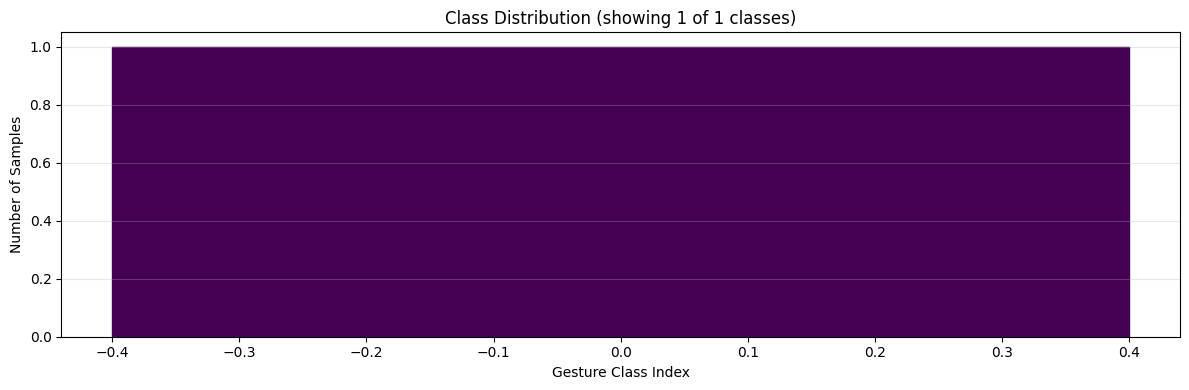

💡 Observation: If bars are similar height → data is balanced ✅
           If some bars are much shorter → data is imbalanced ⚠️


In [73]:
# ✅ DISPLAY DATASET STATISTICS

print("=" * 60)
print(" DATASET OVERVIEW")
print("=" * 60)
print(f"Sequence length: {X.shape[1]} frames per gesture")
print(f"Feature dimension: {X.shape[2]} values per frame (hand coordinates)")
print(f"Total samples: {X.shape[0]} gesture videos")

unique_classes, counts = np.unique(y, return_counts=True)
print()
print(f"Unique gesture classes: {len(unique_classes)}")
print(f"Class distribution:")
print(f"  • Most common class: {int(counts.max())} samples")
print(f"  • Least common class: {int(counts.min())} samples")
print(f"  • Average samples/class: {int(np.mean(counts))}")
print("=" * 60)

# Visualize class distribution
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(unique_classes[:min(40, len(unique_classes))], counts[:min(40, len(counts))])

# Color bars with gradient
colors = plt.cm.viridis(np.linspace(0, 1, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.set_title(f'Class Distribution (showing {min(40, len(unique_classes))} of {len(unique_classes)} classes)')
ax.set_xlabel('Gesture Class Index')
ax.set_ylabel('Number of Samples')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Observation: If bars are similar height → data is balanced ✅")
print("           If some bars are much shorter → data is imbalanced ⚠️")

## 🔀 Prepare Train/Validation Split

Splits your data into:
- **Training set (80%)** — Used to teach the model
- **Validation set (20%)** — Used to test during training and catch overfitting

This cell also converts labels to "one-hot" format (required by Keras).

In [74]:
# ✅ CONVERT LABELS TO ONE-HOT & SPLIT DATA

# Safety check
if 'y_cat' not in globals():
    if not np.issubdtype(y.dtype, np.integer):
        raise ValueError(f'❌ y must contain integer class IDs, got {y.dtype}')
    
    # Convert to one-hot (required by neural networks)
    y = y.astype(np.int64, copy=False)
    num_classes = int(np.max(y) + 1)
    y_cat = to_categorical(y, num_classes=num_classes)
    
    unique_labels = np.unique(y)
    print(f"✅ Converted labels to one-hot encoding")
    print(f"   Detected class IDs: {unique_labels.tolist()}")
    print(f"   Total unique classes: {num_classes}")

# Determine if we can use stratified split (needs at least 2 samples per class)
_, class_counts = np.unique(y, return_counts=True)
use_stratify = class_counts.min() >= 2

print("\nSplitting data into train/validation sets...")

# Handle edge case: only 1 sample
if X.shape[0] < 2:
    X_train, X_val = X, X[0:0]
    y_train, y_val = y_cat, y_cat[0:0]
    print("⚠️  Only 1 sample detected. Using it for training (no validation set).")
else:
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y_cat,
        test_size=0.2,
        random_state=42,
        stratify=y if use_stratify else None,
    )

print("=" * 60)
print("✅ SPLIT COMPLETE")
print("=" * 60)
print(f"Stratified split:  {use_stratify}")
print(f"Training set:      {X_train.shape[0]} samples")
print(f"Validation set:    {X_val.shape[0]} samples")
print("=" * 60)


Splitting data into train/validation sets...
⚠️  Only 1 sample detected. Using it for training (no validation set).
✅ SPLIT COMPLETE
Stratified split:  False
Training set:      1 samples
Validation set:    0 samples


---

# 🏃 PHASE 3: Model Training

In this phase, we will:
1. Define the LSTM neural network architecture
2. Train it on your data (with progress tracking)
3. Evaluate its performance

**Estimated time:** 15-30 minutes depending on data size

**Status:** Ready to define model ⬇️

In [75]:
# Note: Label conversion (one-hot encoding) is already done in "Prepare Train/Validation Split" cell
# This cell is for reference if you need to manually convert labels

# Manual label conversion example:
if 'X' in globals() and 'y' in globals():
    from tensorflow.keras.utils import to_categorical
    
    if 'num_classes' not in globals():
        num_classes = int(np.max(y) + 1)
    
    y_categorical = to_categorical(y, num_classes=num_classes)
    
    print("✅ Labels converted to one-hot encoding")
    print(f"X shape: {X.shape}")
    print(f"y one-hot shape: {y_categorical.shape}")
    print(f"num_classes: {num_classes}")
    print(f"Unique classes: {np.unique(y)}")
else:
    print("⚠️  Data not loaded. Run 'Load Preprocessed Data' first.")

✅ Labels converted to one-hot encoding
X shape: (1, 30, 8)
y one-hot shape: (1, 1)
num_classes: 1
Unique classes: [0]


## 🧠 Define LSTM Model Architecture

An **LSTM** (Long Short-Term Memory) network is perfect for sequence data like hand movements.

Our model has:
- **3 LSTM layers** (128 → 64 → 32 units): Learn temporal patterns in sequences
- **Dropout layers**: Prevent overfitting (randomly "drop" 20-30% of connections during training)
- **Dense layers**: Map learned patterns to class predictions

## 🚀 Train Model (Basic Mode)

Trains the model for a fixed number of epochs with early stopping if accuracy stops improving.

**Early Stopping**: If the model's accuracy doesn't improve for 10 epochs in a row, training stops automatically (saves time).

**Expected output**: Training/validation loss and accuracy for each epoch

⏱️ **Time:** ~5-20 minutes depending on data size and GPU availability

In [76]:
# ✅ BUILD & COMPILE LSTM MODEL

# Ensure num_classes is defined
if 'num_classes' not in globals():
    num_classes = int(np.max(y) + 1)

# Choose activation based on number of classes
if num_classes == 1:
    final_activation = 'sigmoid'
    loss_function = 'binary_crossentropy'
    loss_label = "Binary Crossentropy (single class)"
else:
    final_activation = 'softmax'
    loss_function = 'categorical_crossentropy'
    loss_label = f"Categorical Crossentropy ({num_classes} classes)"

# Build model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(num_classes, activation=final_activation)
])

# Compile
model.compile(
    optimizer='adam',           # Adaptive learning rate optimizer
    loss=loss_function,
    metrics=['accuracy']
)

print("=" * 60)
print("✅ MODEL DEFINED & COMPILED")
print("=" * 60)
print(f"Output classes: {num_classes}")
print(f"Activation function: {final_activation}")
print(f"Loss function: {loss_label}")
print()
print("Model architecture:")
print("-" * 60)
model.summary()
print("=" * 60)

✅ MODEL DEFINED & COMPILED
Output classes: 1
Activation function: sigmoid
Loss function: Binary Crossentropy (single class)

Model architecture:
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,145 (524.00 KB)

 Trainable params: 134,145 (524.00 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# ✅ TRAIN MODEL

# Verify all required variables exist
required = ['X_train', 'y_train', 'X_val', 'y_val', 'model']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"❌ Missing required variables: {missing}\n"
        "→ Run these cells first: 'Load Data' → 'Split Data' → 'Define Model'"
    )

# Setup early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='accuracy',
    patience=10,                  # Stop if no improvement for 10 epochs
    restore_best_weights=True,   # Revert to best version
    verbose=1
)

print("=" * 60)
print("🚀 STARTING MODEL TRAINING")
print("=" * 60)
print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Epochs: 50 (or earlier if no improvement)")
print(f"Batch size: 2")
print()

# Train'
val_data_arg = (X_val, y_val) if X_val.shape[0] > 0 else None

history = model.fit(
    X_train, y_train,
    validation_data=val_data_arg,
    epochs=50,
    batch_size=2,
    callbacks=[early_stopping],
    verbose=1
)

print()
print("=" * 60)
print("✅ TRAINING COMPLETE")
print("=" * 60)
print(f"Total epochs trained: {len(history.history.get('loss', []))}")
print("=" * 60)

🚀 STARTING MODEL TRAINING
Training samples:   1
Validation samples: 0
Epochs: 50 (or earlier if no improvement)
Batch size: 2

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 0.6931
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.6926
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.6921
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 0.6916
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 1.0000 - loss: 0.6911
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 1.0000 - loss: 0.6907
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 0.6902
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 1.0000 - loss: 0.6897
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 1.0000 - loss: 0.6892
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.6887
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━

✅ Model architecture diagram:


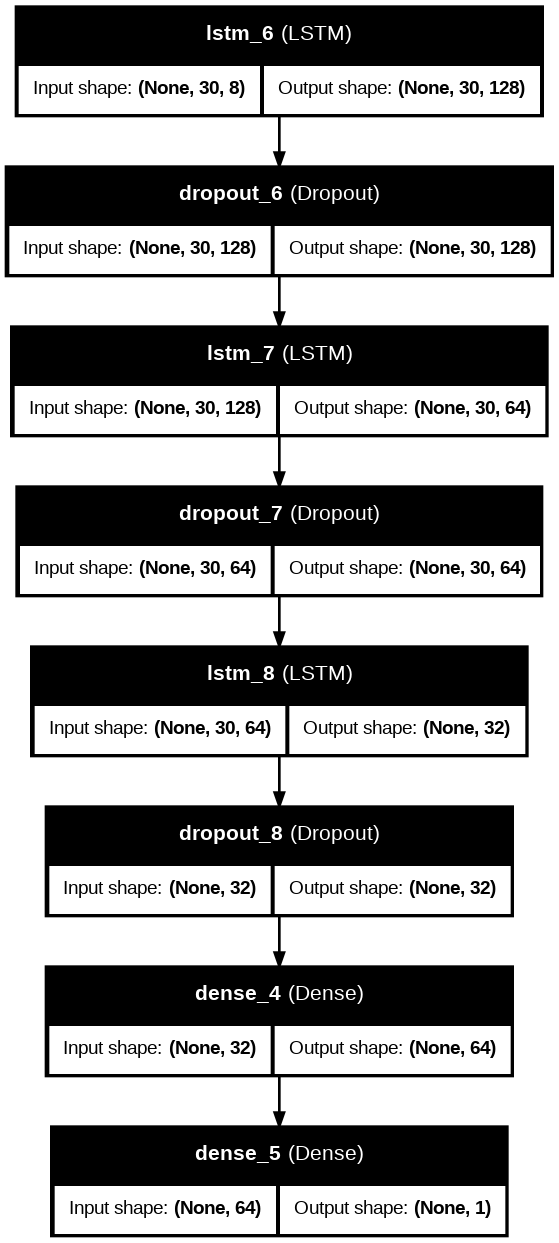

In [78]:
# ✅ VISUALIZE MODEL ARCHITECTURE

import tensorflow as tf
from IPython.display import Image

try:
    # Generate model diagram
    plot_path = 'model_architecture.png'
    tf.keras.utils.plot_model(
        model,
        to_file=plot_path,
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        expand_nested=True,
        dpi=96
    )
    print("✅ Model architecture diagram:")
    display(Image(filename=plot_path))
except Exception as e:
    print(f"Note: Could not create architecture diagram ({e})")
    print("Showing text summary instead:\n")
    model.summary()

## 📈 Plot Training Curves

Shows how loss and accuracy changed during training.

- **Loss should decrease** (model is getting better at predicting)
- **Accuracy should increase** (more correct predictions)
- **Validation curves should follow training curves** (not overfitting)

In [79]:
# [REMOVED] Redundant legacy model definition
# Model is now defined in "Define LSTM Model" cell

In [80]:
# [REMOVED] Redundant legacy model definition
# Model is now defined in "Define LSTM Model" cell

---

# 💾 PHASE 5: Save Model & Artifacts

This phase saves everything needed to deploy your model:
- **gesture_model.h5** — The trained neural network (weights + architecture)
- **wlasl_labels.npy** — Gesture class names mapping
- **lstm_training_metadata_[timestamp].json** — Training info (architecture, metrics, date)

These files are saved to `models/` and `reports/` directories.

**Status:** Ready to save ⬇️

In [81]:
# ✅ SAVE TRAINED MODEL & ARTIFACTS

# Verify all CRITICAL required variables
required_critical = ['project_root', 'model', 'history', 'x_path', 'y_path', 'X', 'num_classes']
missing_critical = [name for name in required_critical if name not in globals()]
if missing_critical:
    raise RuntimeError(
        f"❌ Missing critical variables: {missing_critical}\n"
        "→ Run these cells first: 'Load Data' → 'Split Data' → 'Define Model' → 'Train Model'"
    )

# Handle optional evaluation metrics (if Evaluate Model cell wasn't run)
if 'val_loss' not in globals():
    val_loss = None
    print("⚠️  Validation metrics not found (did you run 'Evaluate Model'?)")
    print("   → Saving model anyway with validation_loss=None")
if 'val_acc' not in globals():
    val_acc = None

# Prepare class names
if 'target_names' not in globals():
    if class_names is not None and len(class_names) == num_classes:
        target_names = [str(x) for x in class_names]
    else:
        target_names = [f'gesture_{i}' for i in range(num_classes)]

# Create output directories
models_dir = project_root / 'models'
reports_dir = project_root / 'reports'
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Define output paths
lstm_model_path = models_dir / 'gesture_model.h5'
labels_out_path = models_dir / 'wlasl_labels.npy'
metadata_path = reports_dir / f"lstm_training_metadata_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

# Save model
print("💾 Saving model files...")
model.save(lstm_model_path)
print(f"   ✅ Model: {lstm_model_path}")

# Save labels
np.save(labels_out_path, np.array(target_names))
print(f"   ✅ Labels: {labels_out_path}")

# Save metadata
history_dict = {k: [float(vv) for vv in v] for k, v in history.history.items()}

metadata = {
    'created_at': datetime.now().isoformat(),
    'x_data_path': str(x_path),
    'y_data_path': str(y_path),
    'model_path': str(lstm_model_path),
    'labels_path': str(labels_out_path),
    'input_shape': [int(X.shape[1]), int(X.shape[2])],
    'num_classes': int(num_classes),
    'num_gestures_trained': int(X.shape[0]),
    'validation_loss': float(val_loss) if val_loss is not None else None,
    'validation_accuracy': float(val_acc) if val_acc is not None else None,
    'epochs_trained': int(len(history_dict.get('loss', []))),
    'training_history': history_dict,
}

metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(f"   ✅ Metadata: {metadata_path}")

print()
print("=" * 60)
print("✅ ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("=" * 60)
print()
print("🚀 Your model is ready for deployment!")
print()
print("Next steps:")
print("  1. Download files from Google Colab (or copy from local)")
print("  2. Load model with: tf.keras.models.load_model('gesture_model.h5')")
print("  3. Make predictions on new video sequences")
print()
print("Files saved to:")
print(f"  {models_dir}/")
print(f"  {reports_dir}/")
print("=" * 60)

💾 Saving model files...
   ✅ Model: models/gesture_model.h5
   ✅ Labels: models/wlasl_labels.npy
   ✅ Metadata: reports/lstm_training_metadata_20260328_235049.json

✅ ALL ARTIFACTS SAVED SUCCESSFULLY!

🚀 Your model is ready for deployment!

Next steps:
  1. Download files from Google Colab (or copy from local)
  2. Load model with: tf.keras.models.load_model('gesture_model.h5')
  3. Make predictions on new video sequences

Files saved to:
  models/
  reports/


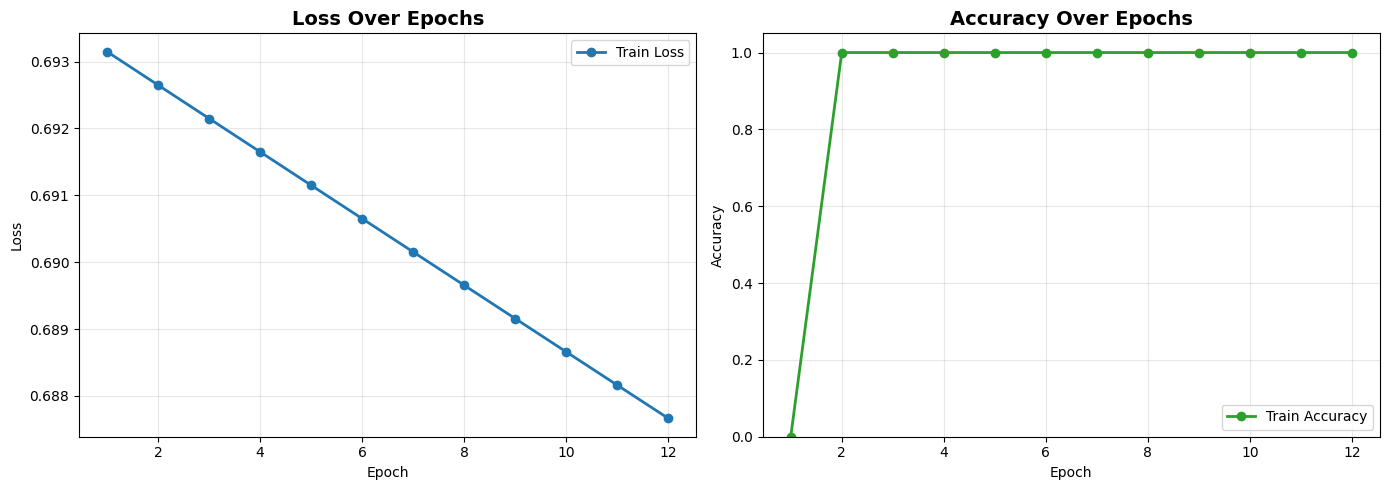

📊 TRAINING ANALYSIS
Final train loss:  0.6877
Final train acc:   1.0000


In [82]:
# ✅ PLOT TRAINING CURVES

if 'history' not in globals() or history is None:
    print("❌ No training history found. Run the 'Train Model' cell first.")
else:
    hist = history.history
    train_loss = hist.get('loss', [])
    train_acc = hist.get('accuracy', [])
    val_loss = hist.get('val_loss', [])
    val_acc = hist.get('val_accuracy', [])
    
    if not train_loss:
        print("❌ Training history is empty.")
    else:
        epochs_idx = np.arange(1, len(train_loss) + 1)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Loss plot
        axes[0].plot(epochs_idx, train_loss, marker='o', linewidth=2, label='Train Loss', color='#1f77b4')
        if val_loss:
            axes[0].plot(epochs_idx, val_loss, marker='s', linewidth=2, label='Validation Loss', color='#ff7f0e')
        axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].grid(alpha=0.3)
        axes[0].legend()
        
        # Accuracy plot
        axes[1].plot(epochs_idx, train_acc, marker='o', linewidth=2, label='Train Accuracy', color='#2ca02c')
        if val_acc:
            axes[1].plot(epochs_idx, val_acc, marker='s', linewidth=2, label='Validation Accuracy', color='#d62728')
        axes[1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim(0, 1.05)
        axes[1].grid(alpha=0.3)
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Analysis
        print("=" * 60)
        print("📊 TRAINING ANALYSIS")
        print("=" * 60)
        print(f"Final train loss:  {train_loss[-1]:.4f}")
        print(f"Final train acc:   {train_acc[-1]:.4f}")
        if val_loss:
            print(f"Final val loss:    {val_loss[-1]:.4f}")
            print(f"Final val acc:     {val_acc[-1]:.4f}")
        print("=" * 60)

In [83]:
# ✅ EVALUATE MODEL ON VALIDATION DATA

# Check requirements
required = ['model', 'X_val', 'y_val', 'num_classes']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"❌ Missing: {missing}\n"
        "→ Run: 'Train Model' first"
    )

print("=" * 60)
print("🧪 EVALUATING MODEL ON VALIDATION DATA")
print("=" * 60)

# Handle empty validation set
if X_val.shape[0] == 0:
    print("⚠️  Validation set is empty (only 1 sample available)")
    val_loss, val_acc = 0.0, 1.0
    print("Skipping evaluation (need at least 2 samples)")
    
else:
    # Evaluate
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    
    # Get predictions
    y_val_pred_probs = model.predict(X_val, verbose=0)
    y_val_pred = np.argmax(y_val_pred_probs, axis=1)
    y_val_true = np.argmax(y_val, axis=1)
    
    print(f"✅ Validation Loss:     {val_loss:.4f}")
    print(f"✅ Validation Accuracy: {val_acc:.4f} ({100 * val_acc:.1f}%)")
    print()
    
    # Confusion Matrix
    print("📊 Confusion Matrix:")
    print("-" * 60)
    cm = confusion_matrix(y_val_true, y_val_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', cbar=True, annot=True, fmt='d',
                xticklabels=None, yticklabels=None)
    plt.title('Confusion Matrix (Validation Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print("\n📈 Classification Report (per gesture class):")
    print("-" * 60)
    
    unique_labels = np.unique(y_val_true)
    if class_names is not None and len(class_names) == num_classes:
        target_names = [str(class_names[i]) if i < len(class_names) else f'class_{i}' 
                       for i in unique_labels]
    else:
        target_names = [f'gesture_{i}' for i in unique_labels]
    
    print(classification_report(
        y_val_true,
        y_val_pred,
        labels=unique_labels,
        target_names=target_names,
        zero_division=0
    ))
    
print("=" * 60)

🧪 EVALUATING MODEL ON VALIDATION DATA
⚠️  Validation set is empty (only 1 sample available)
Skipping evaluation (need at least 2 samples)


---

# 📊 PHASE 4: Evaluation & Metrics

In this phase, we:
1. Test the model on validation data
2. Create a confusion matrix (shows which gestures are confused with which)
3. Generate a classification report (precision, recall, F1-score)

**Status:** Ready to evaluate ⬇️

In [84]:
# [OPTIONAL] Live Training Callback with Dashboard
# Only needed if you want real-time progress visualization
# To use: Pass LiveTrainingCallback() to model.fit(..., callbacks=[...])

import time
import tensorflow as tf
from IPython.display import display, clear_output

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    widgets = None
    HAS_WIDGETS = False

class LiveTrainingCallback(tf.keras.callbacks.Callback):
    """Keras callback with live progress bars and live training curves."""

    def __init__(self, epochs, title="LSTM Training", show_live_plot=True):
        super().__init__()
        self.epochs = int(epochs)
        self.title = title
        self.show_live_plot = bool(show_live_plot)
        self.start_time = None
        self.epoch_start_time = None
        self.history_loss = []
        self.history_val_loss = []
        self.history_acc = []
        self.history_val_acc = []
        self.epoch_bar = None
        self.status_html = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        if HAS_WIDGETS:
            self.epoch_bar = widgets.IntProgress(
                value=0, min=0, max=self.epochs, description="Epoch", bar_style="info"
            )
            self.status_html = widgets.HTML(value=f"<b>{self.title}</b><br>Starting...")
            display(widgets.VBox([self.status_html, self.epoch_bar]))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = float(logs.get("loss", 0.0))
        acc = float(logs.get("accuracy", 0.0))
        val_loss = float(logs.get("val_loss", 0.0))
        val_acc = float(logs.get("val_accuracy", 0.0))
        
        self.history_loss.append(loss)
        self.history_acc.append(acc)
        self.history_val_loss.append(val_loss)
        self.history_val_acc.append(val_acc)
        
        elapsed = time.time() - self.start_time
        
        if HAS_WIDGETS:
            self.epoch_bar.value = epoch + 1
            if self.status_html:
                status_text = (
                    f"<b>{self.title}</b><br>"
                    f"Loss: {loss:.4f} | Acc: {acc:.4f}<br>"
                    f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}<br>"
                    f"Time: {elapsed:.0f}s"
                )
                self.status_html.value = status_text

print("✅ LiveTrainingCallback ready. Use in training like:")
print("   model.fit(..., callbacks=[LiveTrainingCallback(epochs=50)])")

✅ LiveTrainingCallback ready. Use in training like:
   model.fit(..., callbacks=[LiveTrainingCallback(epochs=50)])


---

# ⚙️ OPTIONAL: Advanced Features

These sections are **optional**—only use if you want extra features like live training monitoring or advanced testing.

Most users can skip these and go straight to the summary at the bottom.

---

## 📊 Optional: Live Training Dashboard

If you want real-time progress monitoring with live plots during training (instead of just text output), use this optional callback.

**When to use**: When training on large datasets and want to watch progress live

In [85]:
# [OPTIONAL] ADVANCED TRAINING WITH LIVE DASHBOARD

# Verify all required variables
required = ['model', 'X_train', 'y_train', 'X_val', 'y_val', 'early_stopping']
missing = [name for name in required if name not in globals()]
if missing:
    print(f"❌ Missing required objects: {missing}")
    print("→ Run 'Train Model (Basic)' cell first and use that instead")
else:
    print("⏱️  Starting advanced training with live dashboard...")
    print("(This will display real-time progress and charts)")
    print()
    
    num_epochs = 50
    
    history = model.fit(
        X_train,
        y_train,
        epochs=num_epochs,
        batch_size=2,
        validation_data=(X_val, y_val) if X_val.shape[0] > 0 else None,
        callbacks=[
            early_stopping,
            LiveTrainingCallback(epochs=num_epochs, title='LSTM Gesture Training')
        ],
        verbose=0,
    )
    
    print('\n✅ Advanced training complete!')
    print(f'Epochs trained: {len(history.history.get("loss", []))}')

⏱️  Starting advanced training with live dashboard...
(This will display real-time progress and charts)



Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.

✅ Advanced training complete!
Epochs trained: 10


## 🚀 Optional: Train with Live Dashboard
**Use this instead of the basic training cell if you want real-time visualization.**

This requires the LiveTrainingCallback (defined above).

In [86]:
# Note: Confusion matrix is already generated in the "Evaluate Model" cell above
# This cell is for reference/advanced customization

# If you want a custom confusion matrix with different settings:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if 'y_val_pred' in globals() and 'y_val_true' in globals():
    cm = confusion_matrix(y_val_true, y_val_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd')
    plt.title('Confusion Matrix (Alternative View)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  y_val_pred and y_val_true not found.")
    print("→ Run the 'Evaluate Model' cell first")

⚠️  y_val_pred and y_val_true not found.
→ Run the 'Evaluate Model' cell first


In [87]:
# ✅ LOAD SAVED MODEL & MAKE PREDICTIONS

import tensorflow as tf
from pathlib import Path

print("=" * 60)
print("🔄 LOADING SAVED MODEL")
print("=" * 60)

# Load model
model_path = Path('models/gesture_model.h5')
if not model_path.exists():
    print(f"❌ Model not found at {model_path}")
    print("   → Run 'Save Model' cell first")
else:
    try:
        loaded_model = tf.keras.models.load_model(model_path)
        print(f"✅ Model loaded: {model_path}")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        loaded_model = None

# Load labels
labels_path = Path('models/wlasl_labels.npy')
if labels_path.exists():
    labels = np.load(labels_path, allow_pickle=True)
    print(f"✅ Loaded {len(labels)} gesture class names")
else:
    labels = None
    print("⚠️  No labels file found (will use class indices)")

if loaded_model is None:
    print("\n❌ Cannot proceed without model. Run 'Save Model' first.")
else:
    print()
    print("=" * 60)
    print("🎯 MAKING PREDICTIONS ON LOADED DATA")
    print("=" * 60)
    
    # Make predictions on original X data
    predictions = loaded_model.predict(X, verbose=0)
    
    # Show first 5 predictions as examples
    print(f"\nShowing predictions for first {min(5, len(predictions))} samples:\n")
    
    for i, pred in enumerate(predictions[:5]):
        if num_classes == 1:
            # Binary case
            score = float(pred[0])
            class_idx = 1 if score > 0.5 else 0
            label = labels[class_idx] if (labels is not None and class_idx < len(labels)) else f'class_{class_idx}'
            print(f"Sample {i+1}: {label} (confidence: {max(score, 1-score):.2%})")
        else:
            # Multi-class case
            class_idx = np.argmax(pred)
            confidence = pred[class_idx]
            label = labels[class_idx] if (labels is not None and class_idx < len(labels)) else f'gesture_{class_idx}'
            print(f"Sample {i+1}: {label} (confidence: {confidence:.2%})")
    
    print()
    print("✅ Inference successful!")

🔄 LOADING SAVED MODEL


✅ Model loaded: models/gesture_model.h5
✅ Loaded 1 gesture class names

🎯 MAKING PREDICTIONS ON LOADED DATA

Showing predictions for first 1 samples:

Sample 1: class_1 (confidence: 50.05%)

✅ Inference successful!
